## Setup

In [ ]:
import os
import sys
import atexit

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import torch
import torch.nn as nn
import torch.optim as optim
import logging
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import random 
import threading
import copy 
from copy import deepcopy

sys.path.append('.')
sys.path.append('../Misc')
sys.path.append('/rds/user/ws452/hpc-work/lizarraga_2024/code')

from data_manage import HDF5ImageGenerator  
from modules import EMA, UNet_conditional_conv   
from utils import setup_logging, save_images 
  
from torch.cuda.amp import GradScaler, autocast
from torchvision.utils import make_grid
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import math
import torchvision.transforms.functional as F
import subprocess
from IPython.display import clear_output
import warnings
import h5py
import glob
  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
warnings.filterwarnings('ignore', message='You are using `torch.load` with `weights_only=False`')
warnings.filterwarnings('ignore', message='The verbose parameter is deprecated.*')
warnings.filterwarnings('ignore', message='.*logs will be written to.*')

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# ── Sigma from command line (for SLURM multi-sigma runs) ──────────────────────
LABEL_SIGMA = float(sys.argv[1]) if len(sys.argv) > 1 else 0.1
SIGMA_TAG   = str(LABEL_SIGMA).replace('.', '')   # 0.1 → "01"
print(f"label_sigma = {LABEL_SIGMA}  (tag: s{SIGMA_TAG})")

### Logging configuration

In [ ]:
# Set up directories — named by sigma so different runs don't clash
checkpoint_dir     = f'./Model_Checkpoints_s{SIGMA_TAG}'
tensorboard_log_dir = f'./tens_logs_s{SIGMA_TAG}'
logging_dir        = f'./Logs_s{SIGMA_TAG}'

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(tensorboard_log_dir, exist_ok=True)
os.makedirs(logging_dir, exist_ok=True)

log_file = os.path.join(logging_dir, 'training.log')
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

if logger.hasHandlers():
    logger.handlers.clear()

logger.propagate = False

file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.DEBUG)
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)

formatter = logging.Formatter(
    "%(asctime)s - %(levelname)s: %(message)s",
    datefmt="%I:%M:%S"
)
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info("Logging system initialized")
logger.debug("Debug logging enabled")

In [15]:
def set_random_seed(seed):
    # Set seed for Python's built-in random module
    random.seed(seed)
    
    # Set seed for NumPy
    np.random.seed(seed)
    
    # Set seed for PyTorch
    torch.manual_seed(seed)
    
    # If using CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # For deterministic behavior (may be slower on some systems)
    torch.backends.cudnn.deterministic = True  
    torch.backends.cudnn.benchmark = False

In [16]:
seed = 42   
set_random_seed(seed)

In [17]:
def worker_init_fn(worker_id):
    """
    Initialize each worker with a different random seed based on the worker id.
    """
    worker_seed = torch.initial_seed() % 2**32 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Data process and Normalization

In [18]:
def normalize_images(images):
    """
    Normalize astronomical images to [-1, 1] range using pre-computed dataset statistics.
    
    Args:
        images (torch.Tensor): Raw input images
        
    Returns:
        torch.Tensor: Normalized images in [-1, 1] range
    """
    min_val, max_val = -25241.32, 3647.6323  # Pre-computed statistics
    
    # Input validation
    if torch.isnan(images).any():
        raise ValueError("Input images contain NaN values")
    
    try:
        # Step 1: Scale to [0, 1]
        images = (images - min_val) / (max_val - min_val)
        
        # Clip any potential outliers
        images = torch.clamp(images, 0, 1)
        
        # Step 2: Scale to [-1, 1]
        images = images * 2 - 1
        
        return images
        
    except Exception as e:
        logger.error(f"Normalization failed: {str(e)}")
        raise

def denormalize_images(images):
    """
    Convert normalized images back to original astronomical scale.
    """
    min_val, max_val = -25241.32, 3647.6323
    
    try:
        # Reverse [-1, 1] scaling
        images = (images + 1) / 2
        
        # Reverse [0, 1] scaling
        images = images * (max_val - min_val) + min_val
        
        return images
        
    except Exception as e:
        logger.error(f"Denormalization failed: {str(e)}")
        raise

def get_random_val_batch(val_loader):
    """
    Get a random batch of validation images for visualization.
    """
    val_dataset = val_loader.dataset
    batch_size = val_loader.batch_size
    
    try:
        if len(val_dataset) == 0:
            logger.warning("Empty validation dataset")
            return None, None
            
        # Random sampling with validation
        indices = random.sample(range(len(val_dataset)), batch_size)
        
        images = []
        labels = []
        for idx in indices:
            img, label = val_dataset[idx]
            
            # Validate image and label
            if torch.isnan(img).any():
                logger.warning(f"NaN values found in image at index {idx}")
                continue
                
            images.append(img)
            labels.append(label)
            
        # Stack valid samples
        if not images:
            return None, None
            
        images = torch.stack(images)
        labels = torch.stack(labels)
        
        return images, labels
        
    except Exception as e:
        logger.error(f"Error in random batch selection: {str(e)}")
        return None, None

## Checkpoint

In [19]:
def save_checkpoint(model, ema, optimizer, epoch, checkpoint_dir, args, average_loss, diffusion, best_val_loss):   
    try:
        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch:04d}.pth')
        python_state = random.getstate()
        python_state_list = [python_state[0], list(python_state[1]), python_state[2]]
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'ema_state_dict': ema.state_dict() if ema else None,
            'loss': average_loss,
            'best_val_loss': best_val_loss,   
            'learning_rate': args.lr,
            'batch_size': args.batch_size,
            'diffusion_params': {
                'noise_steps': diffusion.noise_steps,
                'beta_start': diffusion.beta_start,
                'beta_end': diffusion.beta_end
            },
            'args': vars(args),
            'random_state': {
                'python': python_state_list,
                'numpy': np.random.get_state(),
                'torch': torch.get_rng_state(),
                'torch_cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            },
        }
        torch.save(state, checkpoint_path)
        logger.debug(f"Checkpoint saved at epoch {epoch + 1} to {checkpoint_path}")
    except Exception as e:
        logger.error(f"Failed to save checkpoint at epoch {epoch + 1}: {e}")
        raise

def load_checkpoint(model, ema, optimizer, checkpoint_dir, args, diffusion, device, start_epoch=None):
    epoch = 0
    try:
        if start_epoch is None:
            checkpoints = sorted([
                f for f in os.listdir(checkpoint_dir)
                if f.startswith('checkpoint_epoch_') and f.endswith('.pth')
            ])
            if checkpoints:
                latest_checkpoint = os.path.join(checkpoint_dir, checkpoints[-1])
                checkpoint = torch.load(latest_checkpoint, map_location=device, weights_only=False)
                model.load_state_dict(checkpoint['model_state_dict'])
                model.to(device)
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                for state in optimizer.state.values():
                    for k, v in state.items():
                        if isinstance(v, torch.Tensor):
                            state[k] = v.to(device)
                if 'ema_state_dict' in checkpoint and ema is not None:
                    ema.load_state_dict(checkpoint['ema_state_dict'])
                    for k, v in ema.shadow.items():
                        ema.shadow[k] = v.to(device)
                epoch = checkpoint.get('epoch', 0)
                args.lr = checkpoint.get('learning_rate', args.lr)
                args.batch_size = checkpoint.get('batch_size', args.batch_size)
                diffusion_params = checkpoint.get('diffusion_params', None)
                if diffusion_params:
                    diffusion.noise_steps = diffusion_params.get('noise_steps', diffusion.noise_steps)
                    diffusion.beta_start = diffusion_params.get('beta_start', diffusion.beta_start)
                    diffusion.beta_end = diffusion_params.get('beta_end', diffusion.beta_end)
                best_val_loss = checkpoint.get('best_val_loss', float('inf'))
                logger.info(f"Loaded checkpoint from epoch {epoch} with best val loss: {best_val_loss:.4f}")
            else:
                logger.info("No checkpoints found. Starting from scratch.")
    except Exception as e:
        logger.error(f"Failed to load checkpoint: {e}")
        raise
    return epoch

## Diffusion Model

In [20]:
class Diffusion:
   def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=64, device="cuda"):
       """
       Initialize diffusion process parameters.
       
       Args:
           noise_steps: Number of steps to add noise (default 1000)
           beta_start: Initial noise level (default 1e-4)
           beta_end: Final noise level (default 0.02)
           img_size: Size of images (default 64x64)
           device: Device to run on (default "cuda")
       """
       # Basic parameters
       self.noise_steps = noise_steps
       self.beta_start = beta_start
       self.beta_end = beta_end
       
       # Create noise schedule
       self.beta = self.prepare_noise_schedule().to(device)
       # Calculate alpha values (1 - beta)
       self.alpha = 1. - self.beta
       # Calculate cumulative products of alpha
       self.alpha_hat = torch.cumprod(self.alpha, dim=0)
       
       self.img_size = img_size
       self.device = device

   def prepare_noise_schedule(self):
       """Create linear noise schedule from beta_start to beta_end"""
       return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

   def noise_images(self, x, t):
       """
       Add noise to images at timestep t
       
       Args:
           x: Input images， shape: (128, 5, 64, 64)
           t: Timesteps to add noise at
       Returns:
           Noised images and the noise that was added
       """
       # Get alpha values for timesteps
       sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
       sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
       # Generate random noise
       epsilon = torch.randn_like(x)    # noise has same shape as image
       # Return noised image and the noise
       return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

   def sample_timesteps(self, n):
       """Generate n random timesteps between 1 and noise_steps"""
       return torch.randint(low=1, high=self.noise_steps, size=(n,))

   def sample(self, model, n, labels):
       """
       Generate n new images using the diffusion model
       
       Args:
           model: UNet model for noise prediction
           n: Number of images to generate
           labels: Redshift labels to condition on
       """
       logging.info(f"Sampling {n} new images....")
       model.eval()
       with torch.no_grad():
           # Start from random noise
           x = torch.randn((n, 5, self.img_size, self.img_size)).to(self.device)
           
           # Gradually denoise the images
           for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
               t = (torch.ones(n) * i).long().to(self.device)
               # Predict noise at current step
               predicted_noise = model(x, t, labels)
               # Get alpha values for current step
               alpha = self.alpha[t][:, None, None, None]
               alpha_hat = self.alpha_hat[t][:, None, None, None]
               beta = self.beta[t][:, None, None, None]
               
               # Add random noise except at final step
               if i > 1:
                   noise = torch.randn_like(x)
               else:
                   noise = torch.zeros_like(x)
                   
               # Denoising step
               x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
       
       model.train()
       return x

## Best Model Saving

In [21]:
def save_best_model(model, ema, optimizer, epoch, val_loss, best_model_path, args, average_loss, diffusion):
   """
   Saves the best model based on validation loss with enhanced error handling.
   
   Args:
       model: The UNet model to save
       ema: Exponential Moving Average model
       optimizer: The optimizer state
       epoch: Current epoch number
       val_loss: Current validation loss
       best_model_path: Where to save the model
       args: Training arguments and config
       average_loss: Average training loss
       diffusion: Diffusion model parameters
   """
   try:
       # Create dictionary containing all states we want to save
       state = {
           # Training progress
           'epoch': epoch,                                    # Current epoch
           'loss': average_loss,                             # Training loss
           'val_loss': val_loss,                             # Current validation loss
           'best_val_loss': val_loss,                        # Best validation loss (same as val_loss for best model)
           
           # Model states
           'model_state_dict': model.state_dict(),           # Main model weights
           'optimizer_state_dict': optimizer.state_dict(),    # Optimizer state
           'ema_state_dict': ema.state_dict() if ema else None,  # EMA model weights if exists
           
           # Training configuration
           'learning_rate': args.lr,                         # Current learning rate
           'batch_size': args.batch_size,                    # Batch size used
           
           # Diffusion model parameters
           'diffusion_params': {
               'noise_steps': diffusion.noise_steps,         # Number of noise steps
               'beta_start': diffusion.beta_start,           # Starting noise value
               'beta_end': diffusion.beta_end               # Ending noise value
           },
           
           # Full configuration
           'args': vars(args),                              # All training arguments
           
           # Random states for reproducibility
           'random_state': {
               'python': random.getstate(),                  # Python random state
               'numpy': np.random.get_state(),               # NumPy random state
               'torch': torch.get_rng_state(),               # PyTorch CPU random state
               'torch_cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,  # GPU random state
           },
       }
       
       # Save the state dictionary
       torch.save(state, best_model_path)
       logger.debug(f"Best model saved at epoch {epoch + 1} with validation loss {val_loss:.4f}")
       
   except Exception as e:
       # Log error if saving fails
       logger.error(f"Failed to save best model: {e}")
       raise  # Re-raise the exception for the caller to handle

## Training Args

fix paramter

In [ ]:
# Define the Args class
class Args:
    def __init__(self):
        self.resume = True  # Set to True to resume training from the latest checkpoint
        self.run_name = "DDPM_conditional_continuous"
        self.batch_size = 128
        self.epochs = 600
        self.image_size = 64
        self.train_path = '/rds/user/ws452/hpc-work/lizarraga_2024/data/5x64x64_training_with_morphology.hdf5'
        self.validation_path = '/rds/user/ws452/hpc-work/lizarraga_2024/data/5x64x64_validation_with_morphology.hdf5'
        self.test_path = '/rds/user/ws452/hpc-work/lizarraga_2024/data/5x64x64_testing_with_morphology.hdf5'

        # self.train_path = '/Users/wen/Desktop/project/archive/5x64x64_training_with_morphology.hdf5'
        # self.validation_path = '/Users/wen/Desktop/project/archive/5x64x64_validation_with_morphology.hdf5'
        # self.test_path = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'
        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
        self.lr = 2e-5
        self.start_epoch = None  # Set this to specify a specific checkpoint epoch, or None for the latest
        self.seed = 42

## Model Validation

use validation set to evaluates model performance.

In [23]:
def validate(model, val_loader, diffusion, device, loss_fn):
   """
   Validate the model and return the average validation loss.
   
   Args:
       model: The UNet model being trained
       val_loader: DataLoader for validation data
       diffusion: Diffusion process instance
       device: Device (CPU/GPU) to run validation on
       loss_fn: Loss function (Smooth L1/Huber loss)
   Returns:
       avg_loss: Average loss across all validation batches
   """
   # Set model to evaluation mode (disables dropout, etc.)
   model.eval()
   total_loss = 0.0
   batch_count = 0
   
   # Disable gradient computation for validation
   with torch.no_grad():
       for images, labels in val_loader:
           # Move data to appropriate device
           images = images.to(device)
           labels = labels.float().to(device)
           
           # Ensure labels have correct shape (Batch x 1)
           if labels.dim() == 0:  # Single value
               labels = labels.unsqueeze(0).unsqueeze(1)
           elif labels.dim() == 1:  # Batch of values
               labels = labels.unsqueeze(1)
           
           # Preprocess images and add noise
           images = normalize_images(images)  # Scale to [-1, 1]
           t = diffusion.sample_timesteps(images.size(0)).to(device)  # Get random timesteps
           x_t, noise = diffusion.noise_images(images, t)  # Add noise to images
           
           # Get model's noise prediction
           predicted_noise = model(x_t, t, labels)
           
           # Calculate loss between real and predicted noise
           loss = loss_fn(noise, predicted_noise)
           total_loss += loss.item()
           batch_count += 1
           
   # Calculate average loss across all batches
   avg_loss = total_loss / batch_count
   logger.debug(f"Validation completed with average loss: {avg_loss:.4f}")
   
   # Return model to training mode
   model.train()
   return avg_loss

## Data Loading

In [24]:
# Initialize arguments from Args class
args = Args()

# Data generator arguments for training data
train_gen_args = {
   'X_key': 'image',              # Key for accessing image data in HDF5
   'y_key': 'specz_redshift',     # Key for accessing redshift labels
   'scaler': False,               # Don't scale the input images
   'labels_encoding': False,       # No encoding needed for continuous redshift values
   'num_classes': None,           # Not using classification
   'shuffle': True,               # Shuffle data during training
   'y_scaler': False,             # Don't scale the redshift values
   'y_range': (0, 4),            # Redshift range from 0 to 4
   'augmenter': False,            # No data augmentation
   'smooth_factor': 0.1,          # Small smoothing factor for labels
}

# Similar arguments for validation data, but with shuffle=False
val_gen_args = {
   'X_key': 'image',
   'y_key': 'specz_redshift', 
   'scaler': False,
   'labels_encoding': False,
   'num_classes': None,
   'shuffle': False,              # Don't shuffle validation data
   'y_scaler': False,
   'y_range': (0, 4),
   'augmenter': False,
   'smooth_factor': 0.1,
}

# Initialize HDF5 dataset for training
train_dataset = HDF5ImageGenerator(
   src=args.train_path,           # Path to training HDF5 file
   mode='train',                  # Training mode
   X_key='image',                 # Access images in HDF5
   y_key='specz_redshift',        # Access redshifts in HDF5
   scaler=False,                  # Raw image values
   labels_encoding=False,         # Raw redshift values
   num_classes=None,              # Not using classification
   shuffle=False,                 # DataLoader will handle shuffling
   y_scaler=False,               # Keep original redshift scale
   y_range=(0, 4),               # Valid redshift range
   augmenter=False,              # No augmentation
   smooth_factor=0.1             # Small label smoothing
)

# Initialize HDF5 dataset for validation
val_dataset = HDF5ImageGenerator(
   src=args.validation_path,      # Path to validation HDF5 file
   mode='test',                   # Test/validation mode
   X_key='image',
   y_key='specz_redshift',
   scaler=False,
   labels_encoding=False,
   num_classes=None,
   shuffle=False,
   y_scaler=False,
   y_range=(0, 4),
   augmenter=False,
   smooth_factor=0.1
)

# Create PyTorch DataLoader for efficient batching and parallel loading
train_loader = DataLoader(
   train_dataset,
   batch_size=args.batch_size,    # Batch size from Args
   shuffle=True,                  # Shuffle training data
   num_workers=4,                 # Use 4 parallel processes
   pin_memory=True               # Speed up GPU transfer
)

# Validation DataLoader
val_loader = DataLoader(
   val_dataset,
   batch_size=args.batch_size,
   shuffle=False,                 # Don't shuffle validation data
   num_workers=4,                 # Use 4 parallel processes
   pin_memory=True               # Speed up GPU transfer
)

## Data Inspection

Whether dataset is loaded correctly, view samples.

In [25]:
def inspect_labels(dataset, device, num_samples=3, plot_histogram=False):
    """
    Inspects labels in the dataset by displaying the first few images with their redshifts
    and optionally plotting a histogram of all redshift labels.
    """
    try:
        # Only print these three pieces of information
        print(f"Dataset type: {type(dataset)}")
        print(f"Dataset length: {len(dataset)}")
        print(f"Accessing indices: {list(range(num_samples))}")
        
        # Get the samples silently
        images_batch, labels_batch = zip(*[dataset[i] for i in range(num_samples)])
        
        # Process without printing
        images_batch = [img.float() for img in images_batch]
        labels_batch = [label.float() if isinstance(label, torch.Tensor) else torch.tensor(label, dtype=torch.float32) for label in labels_batch]

        # Stack tensors and move to device
        images = torch.stack(images_batch).to(device, non_blocking=True)
        labels = torch.stack(labels_batch).to(device)

        # Silently check for NaNs or Infs
        has_nans = torch.isnan(images).any() or torch.isnan(labels).any()
        has_infs = torch.isinf(images).any() or torch.isinf(labels).any()

        # Silently verify label range
        min_label, max_label = labels.min().item(), labels.max().item()
        expected_min, expected_max = 0, 4
        
        # Display images with their corresponding raw redshift labels
        plt.figure(figsize=(15, 5))
        for j in range(num_samples):
            label = labels[j].item()
            # Normalize and prepare image for display
            image_normalized = (images[j] + 1) / 2
            image_normalized = image_normalized.mean(dim=0).cpu().numpy()
            plt.subplot(1, num_samples, j + 1)
            plt.imshow(image_normalized, cmap='gray')
            plt.title(f"Redshift: {label:.4f}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()

        if plot_histogram:
            original_labels = []
            # Collect labels with progress bar
            for i in tqdm(range(len(dataset)), desc="Collecting labels for histogram"):
                current_label = dataset[i][1]
                if isinstance(current_label, torch.Tensor):
                    current_label = current_label.item()
                original_labels.append(current_label)

            if original_labels:
                original_labels = np.array(original_labels)
                # Plot histogram without additional prints
                plt.figure(figsize=(10, 6))
                plt.hist(original_labels, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
                plt.title("Redshift Labels Distribution")
                plt.xlabel("Redshift Value")
                plt.ylabel("Frequency")
                plt.grid(axis='y', alpha=0.75)
                plt.tight_layout()
                plt.show()

    except Exception as e_outer:
        print(f"Error during label inspection: {e_outer}")


Dataset type: <class 'data_manage.HDF5ImageGenerator'>
Dataset length: 204573
Accessing indices: [0, 1, 2]


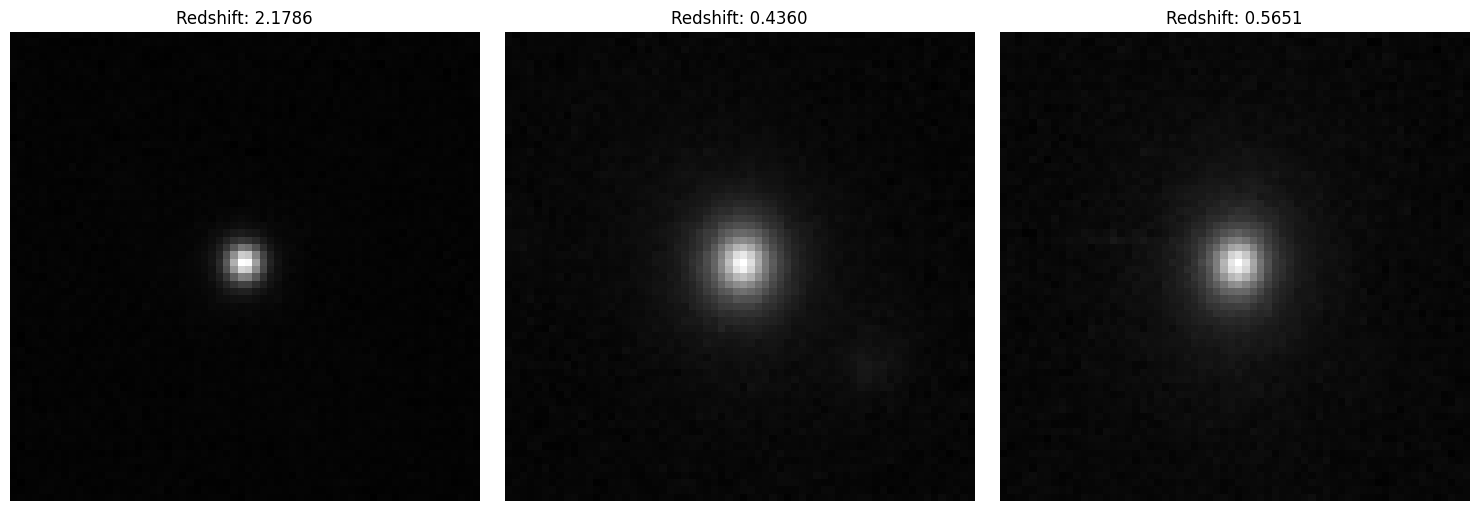

In [26]:
inspect_labels(train_dataset, device, num_samples=3)

## Tensorboard

In [ ]:
#Initialize and start TensorBoard
tensorboard_log_dir = f"./tens_logs_s{SIGMA_TAG}"
writer = SummaryWriter(tensorboard_log_dir)

tensorboard_port = 6028
tensorboard_command = [
    "/home/ws452/.conda/envs/galaxy/bin/tensorboard",
    f"--logdir={tensorboard_log_dir}",
    f"--port={tensorboard_port}",
    "--bind_all"
]
try:
    tensorboard_process = subprocess.Popen(tensorboard_command)
    time.sleep(5)
    print(f"TensorBoard is now running. You can access it at http://localhost:{tensorboard_port}")
except Exception as e:
    logger.error(f"Failed to start TensorBoard: {e}")

## Checkpoint Cleanup

In [28]:
def cleanup_old_checkpoints(checkpoint_dir, current_epoch, keep_last_n=25):
    """
    Cleans up old checkpoints, keeping only the most recent n checkpoints.
    
    Args:
        checkpoint_dir (str): Directory containing checkpoints
        current_epoch (int): Current training epoch
        keep_last_n (int): Number of most recent checkpoints to keep
    """
   
    
    logger = logging.getLogger(__name__)
    
    try:
        # Get all checkpoint files
        checkpoint_files = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*.pth'))
        
        # Extract epoch numbers and sort files by epoch
        checkpoint_epochs = []
        for f in checkpoint_files:
            try:
                epoch_num = int(f.split('epoch_')[-1].split('.')[0])
                checkpoint_epochs.append((epoch_num, f))
            except ValueError:
                logger.warning(f"Skipping file with invalid epoch format: {f}")
                continue
        
        checkpoint_epochs.sort(key=lambda x: x[0])  # Sort by epoch number
        
        # Keep the most recent n checkpoints
        files_to_delete = checkpoint_epochs[:-keep_last_n] if len(checkpoint_epochs) > keep_last_n else []
        
        # Delete old checkpoints
        for _, filepath in files_to_delete:
            try:
                os.remove(filepath)
                logger.info(f"Deleted old checkpoint: {filepath}")
            except Exception as e:
                logger.error(f"Error deleting checkpoint {filepath}: {str(e)}")
                
        if files_to_delete:
            logger.info(f"Cleaned up {len(files_to_delete)} old checkpoints")
    
    except Exception as e:
        logger.error(f"Error during checkpoint cleanup: {str(e)}")
        logger.exception(e)


## Trianing loop

In [ ]:
# new changed by wy: early stop

def train(args, lr, ema_decay, train_loader, val_loader, writer,
          label_sigma=0.01,        # redshift perturbation sigma
          early_stop_lr=1e-7,      # stop if LR drops below this
          early_stop_delta=1e-4,   # minimum improvement to count as progress
          early_stop_patience=20): # stop if no progress for this many epochs

    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    
    if not logger.handlers:
        ch = logging.StreamHandler()
        ch.setLevel(logging.INFO)
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        fh = logging.FileHandler('training.log')
        fh.setLevel(logging.INFO)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
    
    class MessageFilter(logging.Filter):
        def filter(self, record):
            excluded_messages = [
                "Successfully logged images to TensorBoard",
                "Successfully logged real images to TensorBoard",
                "Generating and logging images for epoch",
                "Generated images range:",
                "Starting training, logs will be written to",   
            ]
            return not any(msg in record.msg for msg in excluded_messages)
    
    for handler in logger.handlers:
        if isinstance(handler, logging.StreamHandler):
            handler.addFilter(MessageFilter())
    
    device = torch.device(args.device)
    checkpoint_dir = f'./Model_Checkpoints_s{SIGMA_TAG}'   # sigma-specific directory
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    logger.info(f"Starting training, logs will be written to: {writer.log_dir}")
    logger.info(f"label_sigma={label_sigma}, checkpoint_dir={checkpoint_dir}, early_stop_lr={early_stop_lr}, early_stop_patience={early_stop_patience}")
    
    model = UNet_conditional_conv(c_in=5, c_out=5, y_dim=1).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    ema = EMA(model, beta=ema_decay)
    ema_model = ema.get_ema_model()
    diffusion = Diffusion(img_size=args.image_size, device=device)
    
    best_val_loss = float('inf')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    
    start_epoch = 0
    if args.resume:
        start_epoch = load_checkpoint(
            model, ema, optimizer, checkpoint_dir, args, diffusion, device, args.start_epoch
        )
        try:
            best_model_checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
            best_val_loss = best_model_checkpoint.get('val_loss', float('inf'))
            logger.info(f"Loaded previous best validation loss: {best_val_loss:.4f}")
        except Exception as e:
            logger.warning(f"Could not load previous best validation loss: {e}, starting from infinity")
    
    total_epochs = args.epochs
    cumulative_loss = 0.0
    total_start_time = time.time()
    no_improve_count = 0   # early stop counter
    
    logger.info(f"Training started, total epochs: {total_epochs}")
    writer.add_text('Run Info', f"Starting training for {total_epochs} epochs.", 0)
    writer.flush()
    
    generated_images = None
    
    for epoch in range(start_epoch, total_epochs):
        if (epoch + 1) % 5 == 0:
            clear_output(wait=True)
        epoch_start_time = time.time()
        model.train()
        epoch_loss = 0.0
        
        with tqdm(train_loader, desc=f"Epoch {epoch + 1}/{total_epochs}") as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.to(device)
                labels = labels.float().to(device)
                if labels.dim() == 0:
                    labels = labels.unsqueeze(0).unsqueeze(1)
                elif labels.dim() == 1:
                    labels = labels.unsqueeze(1)
                labels += torch.randn_like(labels) * label_sigma   # configurable sigma
                labels = torch.clamp(labels, 0, 4)
                t = diffusion.sample_timesteps(images.shape[0]).to(device)
                x_t, noise = diffusion.noise_images(images, t)
                predicted_noise = model(x_t, t, labels)
                loss = nn.functional.smooth_l1_loss(noise, predicted_noise)
                # smooth l1 = huber loss: 
                # if |error| < 1：loss = 0.5 × error²
                # if |error| >= 1：loss = |error| - 0.5
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                ema.step_ema(ema_model, model)
                epoch_loss += loss.item()
                pbar.set_postfix(HuberLoss=loss.item())
                if i % 10 == 0:
                    writer.flush()
    
        avg_epoch_loss = epoch_loss / len(train_loader)
        cumulative_loss += avg_epoch_loss
        writer.add_scalar('Loss/train_epoch', avg_epoch_loss, epoch)
        writer.add_scalar('Learning_Rate', optimizer.param_groups[0]['lr'], epoch)
        writer.flush()
    
        if (epoch + 1) % 2 == 0:
            logger.info(f"Generating and logging images for epoch {epoch + 1}")
            try:
                with torch.no_grad():
                    sample_labels = torch.linspace(0, 4, 16).to(device).unsqueeze(1)
                    generated_images = diffusion.sample(ema_model, 16, sample_labels)
                    generated_images = denormalize_images(generated_images)
                    generated_images_rgb = generated_images[:, :3]
                    generated_images_rgb = (generated_images_rgb - generated_images_rgb.min()) / (generated_images_rgb.max() - generated_images_rgb.min() + 1e-5)
                    grid = make_grid(generated_images_rgb, nrow=4)
                    writer.add_image(f'Generated_Images/epoch_{epoch + 1}', grid, epoch)
            except Exception as e:
                logger.error(f"Error during image generation: {str(e)}")
            try:
                if val_loader is not None:
                    real_images, _ = get_random_val_batch(val_loader)
                    if real_images is not None:
                        real_images = real_images.to(device)[:16]
                        real_images_rgb = real_images[:, :3]
                        real_images_rgb = (real_images_rgb - real_images_rgb.min()) / (real_images_rgb.max() - real_images_rgb.min() + 1e-5)
                        grid_real = make_grid(real_images_rgb, nrow=4)
                        writer.add_image(f'Real_Images/epoch_{epoch + 1}', grid_real, epoch)
            except Exception as e:
                logger.error(f"Error during real image logging: {str(e)}")
            writer.flush()
            save_checkpoint(
                model=model, ema=ema, optimizer=optimizer, epoch=epoch,
                checkpoint_dir=checkpoint_dir, args=args, average_loss=avg_epoch_loss,
                diffusion=diffusion, best_val_loss=best_val_loss
            )
            if (epoch + 1) % 50 == 0:
                cleanup_old_checkpoints(checkpoint_dir, epoch, keep_last_n=25)
    
        if val_loader is not None:
            val_loss = validate(model, val_loader, diffusion, device, torch.nn.functional.smooth_l1_loss)
            scheduler.step(val_loss)
            writer.add_scalar('Loss/validation', val_loss, epoch)
            writer.add_scalar('Best_Val_Loss', best_val_loss, epoch)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                no_improve_count = 0
                save_best_model(
                    model=model, ema=ema, optimizer=optimizer, epoch=epoch,
                    val_loss=val_loss, best_model_path=best_model_path,
                    args=args, average_loss=avg_epoch_loss, diffusion=diffusion
                )
                logger.info(f"New best model saved with validation loss {best_val_loss:.4f}")
            else:
                if val_loss >= best_val_loss - early_stop_delta:
                    no_improve_count += 1
                else:
                    no_improve_count = 0

        # ── Early stopping ────────────────────────────────────────────────────
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar('No_Improve_Count', no_improve_count, epoch)

        if current_lr < early_stop_lr:
            logger.info(f"Early stop: LR={current_lr:.2e} < threshold {early_stop_lr:.2e} at epoch {epoch+1}")
            break

        if no_improve_count >= early_stop_patience:
            logger.info(f"Early stop: no improvement for {early_stop_patience} epochs at epoch {epoch+1}")
            break
    
        writer.flush()
        epoch_end_time = time.time()
        logger.debug(f"Epoch {epoch + 1}/{total_epochs} finished with average loss: {avg_epoch_loss:.4f} in {epoch_end_time - epoch_start_time:.2f} seconds")
    
    total_training_time = time.time() - total_start_time
    final_avg_loss = cumulative_loss / total_epochs
    writer.add_scalar('Loss/final_average', final_avg_loss, total_epochs)
    writer.add_text('Training Time', f'Total training time: {total_training_time:.2f} seconds')
    writer.flush()
    logger.info(f"Training completed in {total_training_time:.2f} seconds with average loss: {final_avg_loss:.4f}")
    
    return final_avg_loss, generated_images

## Start Training

In [ ]:
# Call train function — set label_sigma to match paper ablation (0.01/0.1/0.5/1.0)
average_loss, generated_images = train(
    args,
    lr=args.lr,
    ema_decay=0.995,
    train_loader=train_loader,
    val_loader=val_loader,
    writer=writer,
    label_sigma=0.1,        # σ for redshift perturbation (paper: 0.1 best)
    early_stop_lr=1e-7,     # stop if LR < this
    early_stop_patience=20, # stop if no improvement for 20 epochs
)

## Tensorboard Cleanup

In [ ]:
def shutdown_tensorboard():
    tensorboard_process.terminate()
    tensorboard_process.wait()
    logger.info("TensorBoard has been terminated.")

atexit.register(shutdown_tensorboard)